In [1]:
from pathlib import Path

from matplotlib import pyplot as plt

import json 
import numpy as np

In [2]:
ARTIFACT_DIR = Path("../../artifacts/2023-05-S5/experiment-binary-task")

In [3]:
def load_stats(dataset, model, layer, basis_name):
    
    
    filepath = ARTIFACT_DIR / dataset / model / layer / basis_name / "stats.json"
    
    
    with open(filepath, "r") as fh:
        stats = json.load(fh)

        aurocs = np.array(stats["arr_auroc"])
        
        original_auroc = stats["original_auroc"]
        
        stats["original_auroc_corrected"] = np.max([original_auroc, 1-original_auroc])
        
        stats["arr_auroc_corrected"] = np.where(aurocs < 0.5, 1-aurocs, aurocs)
        
        
        
    return stats
    
    
        
load_stats("cifar100-35vs98", "cifar100-resnet18-p1", "layer1", "pca--centered")

{'arr_auroc': [0.5199999809265137,
  0.5027999877929688,
  0.5005999803543091,
  0.3458999693393707,
  0.2678000032901764,
  0.23899999260902405,
  0.2378999888896942,
  0.2378000020980835,
  0.22800001502037048,
  0.22439999878406525,
  0.22580000758171082,
  0.2184000015258789,
  0.2119000256061554,
  0.21580000221729279,
  0.21559999883174896,
  0.2142999917268753,
  0.21309998631477356,
  0.21379998326301575,
  0.21410001814365387,
  0.21310001611709595,
  0.2136000096797943,
  0.2126999944448471,
  0.21080002188682556,
  0.21000000834465027,
  0.21010001003742218,
  0.20999999344348907,
  0.20880001783370972,
  0.20960000157356262,
  0.20820000767707825,
  0.20819999277591705,
  0.20759999752044678,
  0.2070000171661377,
  0.2069000005722046],
 'arr_ks': [0,
  2,
  4,
  6,
  8,
  10,
  12,
  14,
  16,
  18,
  20,
  22,
  24,
  26,
  28,
  30,
  32,
  34,
  36,
  38,
  40,
  42,
  44,
  46,
  48,
  50,
  52,
  54,
  56,
  58,
  60,
  62,
  64],
 'dims': 64,
 'original_auroc': 0.206

In [4]:
class_pairs = """
cifar100-35vs98
cifar100-46vs98
cifar100-55vs72
cifar100-11vs35
cifar100-11vs46
cifar100-24vs72
cifar100-33vs35
cifar100-27vs84
cifar100-65vs67
cifar100-49vs81
""".strip().split("\n")

class_pairs

['cifar100-35vs98',
 'cifar100-46vs98',
 'cifar100-55vs72',
 'cifar100-11vs35',
 'cifar100-11vs46',
 'cifar100-24vs72',
 'cifar100-33vs35',
 'cifar100-27vs84',
 'cifar100-65vs67',
 'cifar100-49vs81']

In [10]:
def ano():
    
    stat = load_stats("cifar100-35vs98", "cifar100-resnet18-p1", "layer3", "pca--centered")
    for k, v, in zip(stat["arr_ks"], stat["arr_auroc_corrected"]):
        print(f"k={k:3d}, auroc={v:.4f}")
ano()

k=  0, auroc=0.5200
k=  2, auroc=0.6188
k=  4, auroc=0.5610
k=  6, auroc=0.5588
k=  8, auroc=0.5770
k= 10, auroc=0.5931
k= 12, auroc=0.6021
k= 14, auroc=0.6068
k= 16, auroc=0.6258
k= 18, auroc=0.6326
k= 20, auroc=0.6607
k= 22, auroc=0.6714
k= 24, auroc=0.6977
k= 26, auroc=0.6957
k= 28, auroc=0.7019
k= 30, auroc=0.6966
k= 32, auroc=0.7063
k= 34, auroc=0.7143
k= 36, auroc=0.7275
k= 38, auroc=0.7328
k= 40, auroc=0.7394
k= 42, auroc=0.7419
k= 44, auroc=0.7475
k= 46, auroc=0.7512
k= 48, auroc=0.7673
k= 50, auroc=0.7666
k= 52, auroc=0.7712
k= 54, auroc=0.7721
k= 56, auroc=0.7748
k= 58, auroc=0.7756
k= 60, auroc=0.7817
k= 62, auroc=0.7823
k= 64, auroc=0.7812
k= 66, auroc=0.7820
k= 68, auroc=0.7829
k= 70, auroc=0.7850
k= 72, auroc=0.7848
k= 74, auroc=0.7882
k= 76, auroc=0.7861
k= 78, auroc=0.7887
k= 80, auroc=0.7905
k= 82, auroc=0.7917
k= 84, auroc=0.7886
k= 86, auroc=0.7923
k= 88, auroc=0.7931
k= 90, auroc=0.7957
k= 92, auroc=0.7932
k= 94, auroc=0.7968
k= 96, auroc=0.7980
k= 98, auroc=0.7982


In [5]:
def ano():
    
    stat = load_stats("cifar100-35vs98", "cifar100-resnet18-p1", "layer3", "prca--centered")
    for k, v, in zip(stat["arr_ks"], stat["arr_auroc_corrected"]):
        print(f"k={k:3d}, auroc={v:.4f}")
ano()

k=  0, auroc=0.5200
k=  2, auroc=0.6071
k=  4, auroc=0.6177
k=  6, auroc=0.6100
k=  8, auroc=0.6217
k= 10, auroc=0.6411
k= 12, auroc=0.6738
k= 14, auroc=0.7110
k= 16, auroc=0.7298
k= 18, auroc=0.7271
k= 20, auroc=0.7361
k= 22, auroc=0.7448
k= 24, auroc=0.7451
k= 26, auroc=0.7447
k= 28, auroc=0.7541
k= 30, auroc=0.7524
k= 32, auroc=0.7541
k= 34, auroc=0.7586
k= 36, auroc=0.7663
k= 38, auroc=0.7688
k= 40, auroc=0.7675
k= 42, auroc=0.7729
k= 44, auroc=0.7746
k= 46, auroc=0.7758
k= 48, auroc=0.7748
k= 50, auroc=0.7767
k= 52, auroc=0.7771
k= 54, auroc=0.7736
k= 56, auroc=0.7727
k= 58, auroc=0.7736
k= 60, auroc=0.7740
k= 62, auroc=0.7730
k= 64, auroc=0.7761
k= 66, auroc=0.7786
k= 68, auroc=0.7790
k= 70, auroc=0.7796
k= 72, auroc=0.7826
k= 74, auroc=0.7822
k= 76, auroc=0.7801
k= 78, auroc=0.7773
k= 80, auroc=0.7761
k= 82, auroc=0.7786
k= 84, auroc=0.7778
k= 86, auroc=0.7764
k= 88, auroc=0.7773
k= 90, auroc=0.7774
k= 92, auroc=0.7760
k= 94, auroc=0.7755
k= 96, auroc=0.7770
k= 98, auroc=0.7769


In [6]:
difficult_pairs, random_pairs = class_pairs[:5], class_pairs[5:]

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64]
[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128]
[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128, 130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154, 156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180, 182, 184, 186, 188, 190, 192, 194, 196, 198, 200, 202, 204, 206, 208, 210, 212, 214, 216, 218, 220, 222, 224, 226, 228, 230, 232, 234, 236, 238, 240, 242, 244, 246, 248, 250, 252, 254, 256]
[0, 2, 4, 

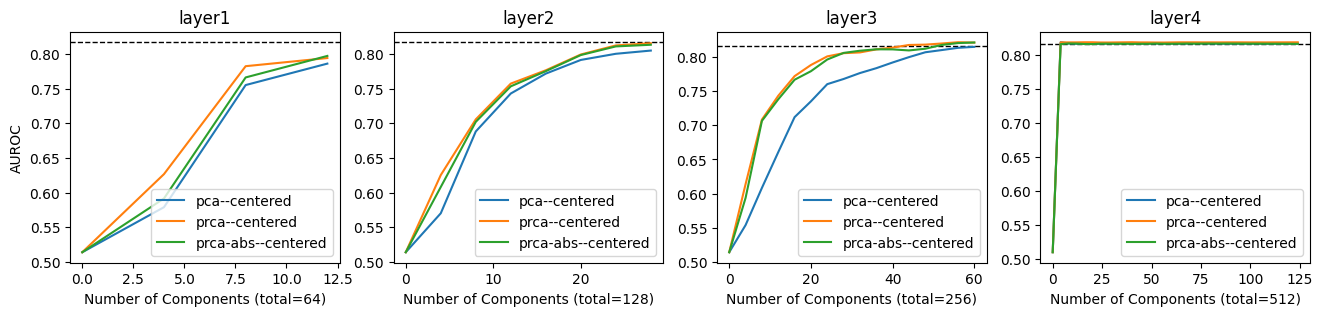

In [7]:
def viz(class_pairs, model="cifar100-resnet18-p1", layers=["layer1", "layer2", "layer3", "layer4"]):
    
    ncols = len(layers)
    
    plt.figure(figsize=(ncols*4, 3))


    basis_names = ["pca--centered", "prca--centered", "prca-abs--centered"]
    
    for lix, layer in enumerate(layers):
                
        arr_ks = load_stats(class_pairs[0], model, layer, basis_names[0])["arr_ks"]
                
        print(arr_ks)
        original_auroc_corrected = []
    
        stat_layer_aurocs = np.zeros((len(class_pairs), len(basis_names), len(arr_ks)))
        
        for pix, pair in enumerate(class_pairs):

            ref_stats = load_stats(pair, model, layer, basis_names[0])
            original_auroc_corrected.append(ref_stats["original_auroc_corrected"])
            for bix, basis_name in enumerate(basis_names):

                stats = load_stats(pair, model, layer, basis_name)

                for k in ["arr_ks", "original_auroc_corrected"]:
                    np.testing.assert_allclose(ref_stats[k], stats[k], err_msg=f"key={k}")
                    
                    
                stat_layer_aurocs[pix, bix, :] = stats["arr_auroc_corrected"]
        
        
        plt.subplot(1, ncols, lix+1)
        plt.title(layer)
        plt.xlabel(f"Number of Components (total={arr_ks[-1]})")
     
    
        plt.axhline(np.mean(original_auroc_corrected), ls="--", lw=1, color="k")
        for bix, basis_name in enumerate(basis_names):
            plt.plot(
                arr_ks[:len(arr_ks)//4][::2],
                np.mean(stat_layer_aurocs[:, bix, :], axis=0)[:len(arr_ks)//4][::2],
                label=basis_name,
#                 marker="."
            )
            
          
        if lix == 0:
            plt.ylabel("AUROC")
        plt.legend() 
viz(difficult_pairs)

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64]
[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128]
[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128, 130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154, 156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180, 182, 184, 186, 188, 190, 192, 194, 196, 198, 200, 202, 204, 206, 208, 210, 212, 214, 216, 218, 220, 222, 224, 226, 228, 230, 232, 234, 236, 238, 240, 242, 244, 246, 248, 250, 252, 254, 256]
[0, 2, 4, 

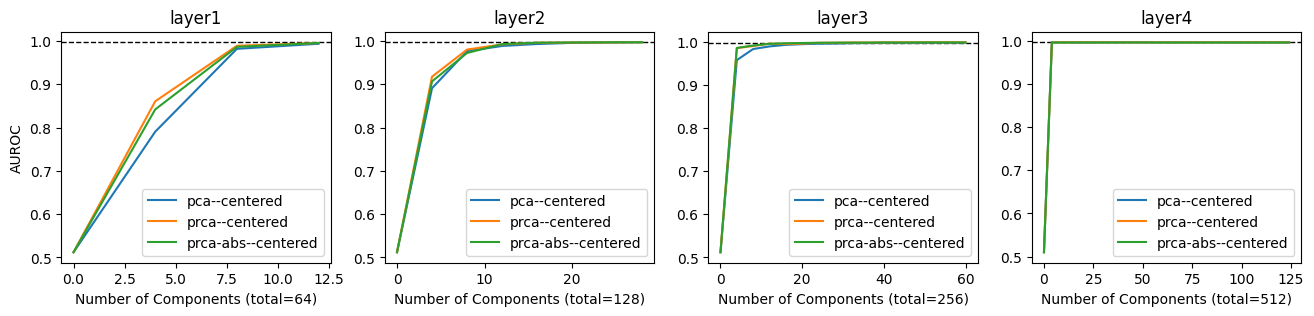

In [8]:
viz(random_pairs)

In [9]:
raise

RuntimeError: No active exception to reraise

In [ ]:
list(range(0, 255 + 2, 2))

PosixPath('../../artifacts/2023-05-S5/experiment-binary-task/cifar100-35vs98/layer3/pca--centered/eigvals.npy')

In [19]:
def ano():

    vals = np.load(ARTIFACT_DIR / "cifar100-35vs98/cifar100-resnet18-p1/layer4/pca--centered/eigvals.npy")
    
    print(vals.shape)
    
    print(vals[:5])
ano()

(512,)
[0.11833616 0.6000764  0.09784915 0.18536952 0.10929094]


In [16]:
ls -la ../../artifacts/2023-05-S5/experiment-binary-task/cifar100-35vs98/cifar100-resnet18-p1/

total 24
drwxr-xr-x 6 pat pat 4096 May  3 15:48 ./
drwxr-xr-x 3 pat pat 4096 May  3 15:48 ../
drwxr-xr-x 5 pat pat 4096 May  3 19:08 layer1/
drwxr-xr-x 5 pat pat 4096 May  3 19:08 layer2/
drwxr-xr-x 5 pat pat 4096 May  3 19:08 layer3/
drwxr-xr-x 5 pat pat 4096 May  3 19:08 layer4/
